# Hybrid Search (Vector & Keyword Searches)

## 1. Problems with pure Vector Search
- Vector search is great at understanding semantic meaning & context
- But it has some *blind spots* that can hurt retrieval quality
- It struggles with exact matches - (E.g. user searching for *API key authentication* but getting results about *user login security*)
- It can miss important keywords that users specifically mention
- Sometimes users know exactly what terms they want to find


This is where **Keyword Search** comes in (The older/classic approach):
- Keyword search looks for exact word matches in your chunks
- It's been around forever (think Google in early 2000s)
- Super reliable for finding specific terms, names, model numbers, technical jargon
- But it's still *dumb* - it doesn't understand that *car* and *automobile* are the same things

## 2. Algorithm behind Keyword Search (BM25)

[BM25](https://docs.langchain.com/oss/python/integrations/retrievers/bm25) (Best Matching 25) is the gold standard for keyword search.

It scores chunks based on 2 Key Factors:

1. **Term Frequency (TF)**: How often does the search term appear in this specific chunk?
2. **Inverse Document Frequency (IDF)**: How rare is this term across your entire chunk collection?

**TF Example**:
> Chunk A says *"Tesla's revenue growth is strong. Tesla reported record profits"*
> 
> Chunk B says *"Tesla reported strong results."*
> 
> *"Tesla"* query give higher TF Score to **Chunk A** because it mentions *"Tesla"* **twice**

**IDF Example**:
> If *"Tesla"* appears in **100 Chunks** but *"Cybertruck"* appears in only **5 Chunks**
> 
> *"Tesla Cybertruck"* query give higher IDF Score to **Chunk B** because it's rarer across all chunks

**Combined:**:
> For query *"Tesla Cybertruck"*,
> 
> Chunk A says *"Tesla's Cybertruck production"*
>
> Chunk B says *"Tesla Tesla, Tesla financial reports"*
>
> Result: Chunk A beats Chunk B, because the term *"Cybertruck"* is rarer and is more valuable than repeated common terms


**BM25** is an improved version of **TF-IDF** that 
- Prevents keyword stuffing
- Handling chunk length better

## 3. Why we need Hybrid Approach

- Vector search catches semantic relationships and context
- Keyword search catches exact matches and specific terminology (important in Biomed field for FYP)
- Together, they cover each other's weakness
- Think of it as having both a smart assistant (vectors) and a precise librarian (keywords) working together

## 4. Hybrid Search (Code)

### 4.1 Dependencies

In [10]:
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document
from dotenv import load_dotenv

load_dotenv()

True

In [11]:
!pip install rank_bm25

  Obtaining dependency information for rank_bm25 from https://files.pythonhosted.org/packages/2a/21/f691fb2613100a62b3fa91e9988c991e9ca5b89ea31c0d3152a3210344f9/rank_bm25-0.2.2-py3-none-any.whl.metadata



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 4.2 Sample Chunks Setup

In [12]:
# ──────────────────────────────────────────────────────────────────
# SETUP: Create our sample company data
# ──────────────────────────────────────────────────────────────────

chunks = [
    "Microsoft acquired GitHub for 7.5 billion dollars in 2018.",
    "Tesla Cybertruck production ramp begins in 2024.",
    "Google is a large technology company with global operations.",
    "Tesla reported strong quarterly results. Tesla continues to lead in electric vehicles. Tesla announced new manufacturing facilities.",
    "SpaceX develops Starship rockets for Mars missions.",
    "The tech giant acquired the code repository platform for software development.",
    "NVIDIA designs Starship architecture for their new GPUs.",
    "Tesla Tesla Tesla financial quarterly results improved significantly.",
    "Cybertruck reservations exceeded company expectations.",
    "Microsoft is a large technology company with global operations.", 
    "Apple announced new iPhone features for developers.",
    "The apple orchard harvest was excellent this year.",
    "Python programming language is widely used in AI.",
    "The python snake can grow up to 20 feet long.",
    "Java coffee beans are imported from Indonesia.", 
    "Java programming requires understanding of object-oriented concepts.",
    "Orange juice sales increased during winter months.",
    "Orange County reported new housing developments."
]

In [15]:
# Convert to Document objects for LangChain
documents = [Document(page_content=chunk, metadata={"source": f"chunk_{i}"}) for i, chunk in enumerate(chunks)]

print("Sample Data:")
for i, chunk in enumerate(chunks, 1):
    print(f"{i}. {chunk}")

print("\n" + "="*80)

Sample Data:
1. Microsoft acquired GitHub for 7.5 billion dollars in 2018.
2. Tesla Cybertruck production ramp begins in 2024.
3. Google is a large technology company with global operations.
4. Tesla reported strong quarterly results. Tesla continues to lead in electric vehicles. Tesla announced new manufacturing facilities.
5. SpaceX develops Starship rockets for Mars missions.
6. The tech giant acquired the code repository platform for software development.
7. NVIDIA designs Starship architecture for their new GPUs.
8. Tesla Tesla Tesla financial quarterly results improved significantly.
9. Cybertruck reservations exceeded company expectations.
10. Microsoft is a large technology company with global operations.
11. Apple announced new iPhone features for developers.
12. The apple orchard harvest was excellent this year.
13. Python programming language is widely used in AI.
14. The python snake can grow up to 20 feet long.
15. Java coffee beans are imported from Indonesia.
16. Java pr

### 4.3 Vector Retriever (Semantic Search/Dense Retrieval)

In [16]:
print("Setting up Vector Retriever...")
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-mpnet-base-v2"
)

vectorstore = Chroma.from_documents(
    documents=documents,
    embedding=embedding_model,
    collection_metadata={"hnsw:space": "cosine"}
)

Setting up Vector Retriever...


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 4908.21it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [17]:
vector_retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

# Test semantic search
test_query = "space exploration company" #works in vector search but wouldn't work with keyword search

print(f"Testing: '{test_query}'")
test_docs = vector_retriever.invoke(test_query)
for doc in test_docs:
    print(f"Found: {doc.page_content}")

Testing: 'space exploration company'
Found: SpaceX develops Starship rockets for Mars missions.
Found: Google is a large technology company with global operations.


### 4.4 BM25 Retriever (Keyword Search/Sparse Retrieval)

In [18]:
# 2. BM25 Retriever (Keyword Search)
print("Setting up BM25 Retriever...")
bm25_retriever = BM25Retriever.from_documents(documents)
bm25_retriever.k = 3

Setting up BM25 Retriever...


In [21]:
# Test exact keyword matching
test_query = "space exploration company"
# test_query = "Cybertruck"
# test_query = "Tesla"

print(f"Testing: '{test_query}'")
test_docs = bm25_retriever.invoke(test_query)
for doc in test_docs:
    print(f"Found: {doc.page_content}")

Testing: 'space exploration company'
Found: Cybertruck reservations exceeded company expectations.
Found: Microsoft is a large technology company with global operations.
Found: Google is a large technology company with global operations.


### 4.5 Hybrid Retriever (Combination)

In [22]:
#  3. Hybrid Retriever (Combination)
print("Setting up Hybrid Retriever...")
hybrid_retriever = EnsembleRetriever(
    retrievers=[vector_retriever, bm25_retriever],
    weights=[0.7, 0.3]  # Equal weight to vector and keyword search
)

print("Setup complete!\n")

Setting up Hybrid Retriever...
Setup complete!



### 4.6 Queries Testing in Hybrid Search

In [23]:
# Query 1: Mixed semantic and exact terms

# Vector search understands "purchase cost" semantically
# BM25 search finds exact "7.5 billion" 
# Hybrid should combine both strengths for best result
test_query = "purchase cost 7.5 billion"

retrieved_chunks = hybrid_retriever.invoke(test_query)
for i, doc in enumerate(retrieved_chunks, 1):
    print(f"{i}. {doc.page_content}")
print()

print("Query 1 shows how hybrid finds exact financial info using both semantic understanding and keyword matching")

1. Microsoft acquired GitHub for 7.5 billion dollars in 2018.
2. The tech giant acquired the code repository platform for software development.
3. Orange County reported new housing developments.
4. Orange juice sales increased during winter months.

Query 1 shows how hybrid finds exact financial info using both semantic understanding and keyword matching


In [24]:
# Query 2: Semantic concept + specific product name  

# Vector search understands "electric vehicle manufacturing"
# BM25 search finds exact "Cybertruck"
# Hybrid gets the best of both worlds

test_query = "electric vehicle manufacturing Cybertruck"

retrieved_chunks = hybrid_retriever.invoke(test_query)

for i, doc in enumerate(retrieved_chunks, 1):
    print(f"{i}. {doc.page_content}")
print()

print("Query 2 demonstrates combining product-specific terms with broader concepts")

1. Tesla Cybertruck production ramp begins in 2024.
2. Cybertruck reservations exceeded company expectations.
3. Tesla reported strong quarterly results. Tesla continues to lead in electric vehicles. Tesla announced new manufacturing facilities.

Query 2 demonstrates combining product-specific terms with broader concepts


In [25]:
# Query 3: Where neither alone would be perfect

# "Company performance" is semantic, "Tesla" is exact keyword
# Hybrid should find the most relevant Tesla performance info

test_query = "company performance Tesla"

retrieved_chunks = hybrid_retriever.invoke(test_query)
for i, doc in enumerate(retrieved_chunks, 1):
    print(f"{i}. {doc.page_content}")
print()

print("Query 3 shows how hybrid handles mixed semantic/keyword queries better than either approach alone")

1. Tesla Tesla Tesla financial quarterly results improved significantly.
2. Tesla reported strong quarterly results. Tesla continues to lead in electric vehicles. Tesla announced new manufacturing facilities.
3. Cybertruck reservations exceeded company expectations.

Query 3 shows how hybrid handles mixed semantic/keyword queries better than either approach alone


### 4.7 LLM Generation

In [26]:
test_query = "company performance Tesla"

retrieved_chunks = hybrid_retriever.invoke(test_query)

In [28]:
# Combine the query and the relevant document contents
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI


combined_input = f"""Based on the following documents, please answer this question: {test_query}

Documents:
{chr(10).join([f"- {doc.page_content}" for doc in retrieved_chunks])}

Please provide a clear, helpful answer using only the information from these documents. If you can't find the answer in the documents, say "I don't have enough information to answer that question based on the provided documents."
"""

# Create a ChatOpenAI model
model = ChatOpenAI(model="gpt-4o-mini")

# Define the messages for the model
messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content=combined_input),
]

# Invoke the model with the combined input
result = model.invoke(messages)

# Display the full result and content only
print("\n--- Generated Response ---")
print("Full result:")
print(result)
print("Content only:")
print(result.content)


--- Generated Response ---
Full result:
content="Based on the provided documents, Tesla's performance has improved significantly. The company reported strong quarterly results and continues to lead in the electric vehicle market. Additionally, Tesla announced new manufacturing facilities, and reservations for the Cybertruck exceeded company expectations." additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 115, 'total_tokens': 162, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_47b921f3df', 'id': 'chatcmpl-DKOEPoLNOP0jmOqz7b8ttmVuw0iwx', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019cfbdc-ca69-7743-ac93-feaad6115087-0' tool_calls=[] inval

## 5. Ensemble Retriver RRF With Weights (Vector=0.7, Keyword=0.3)

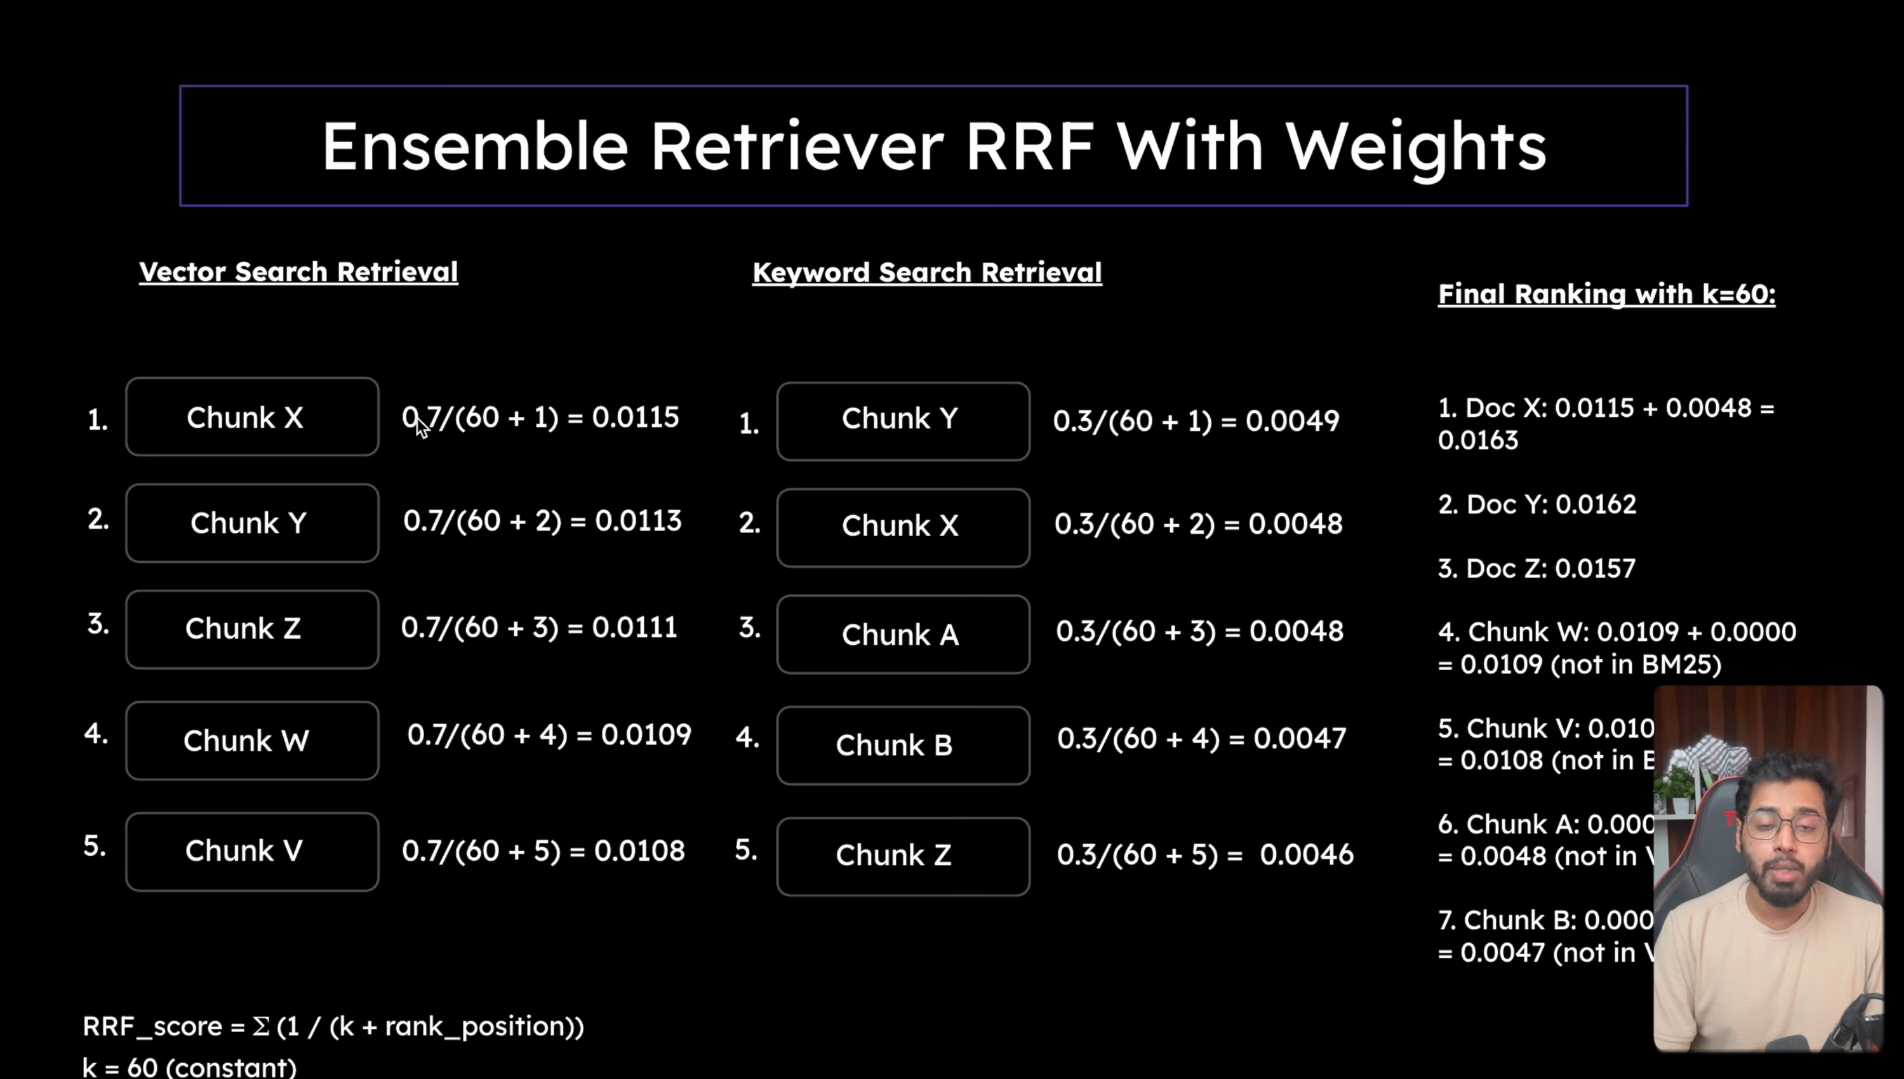


## 6. Reality - Production Scaling

For 10,000 - 20,000 Documents in RAG, single query case:
- Retrieve 30 - 50 Chunks from Vector Search
- Retrieve 30 - 50 Chunks from Keyword Search
- Result from Ensemble Retriever RRF - 30 Chunks
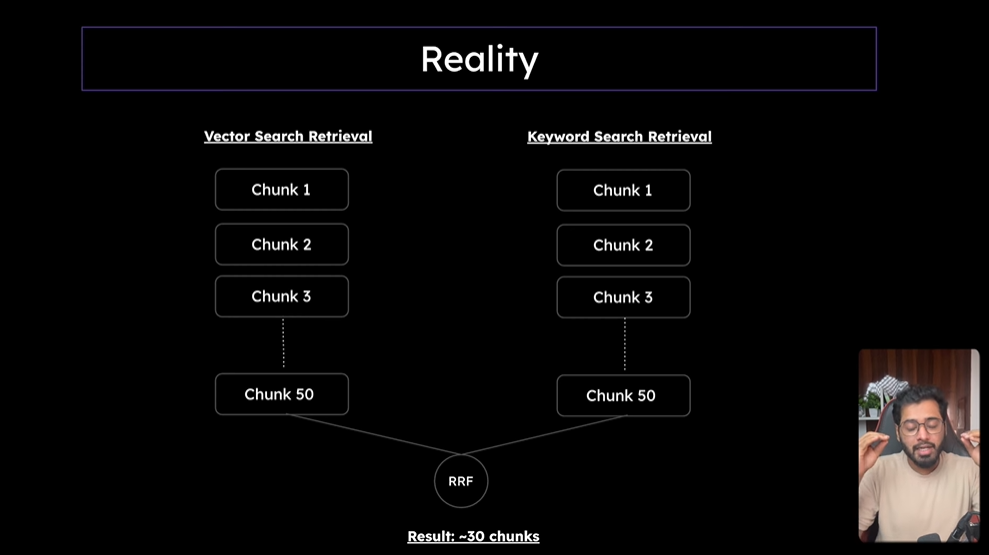

### 6.1 Multiquery + Hybrid Search

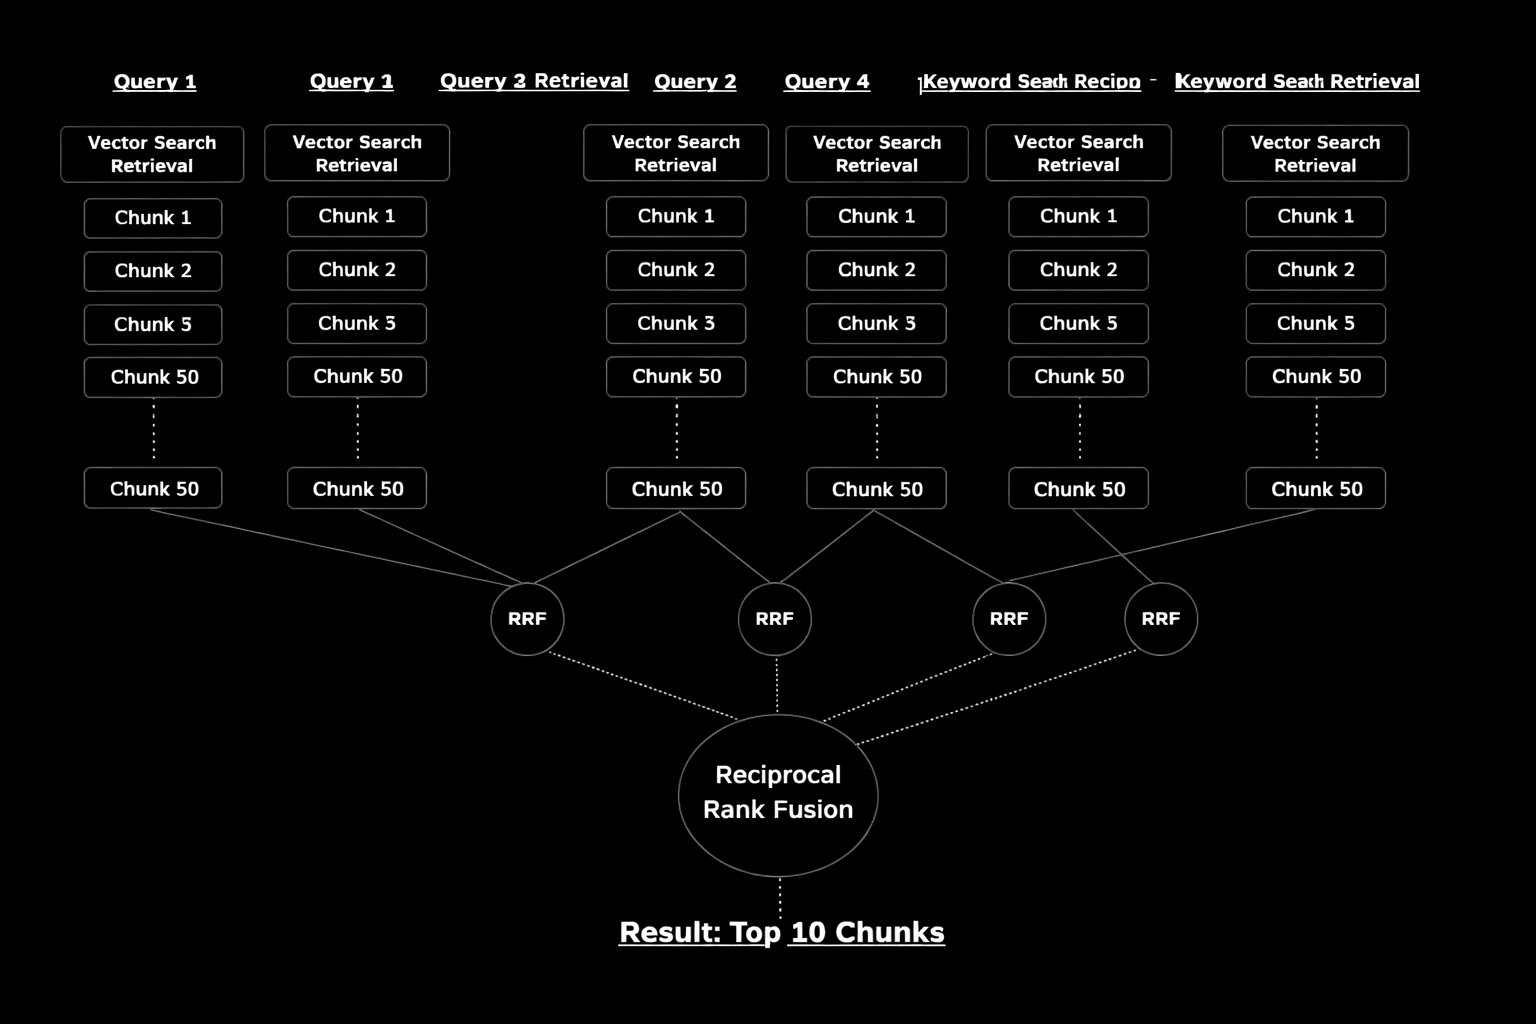

Or Using Reranker!

### 6.2 Reranker (Next Topic)
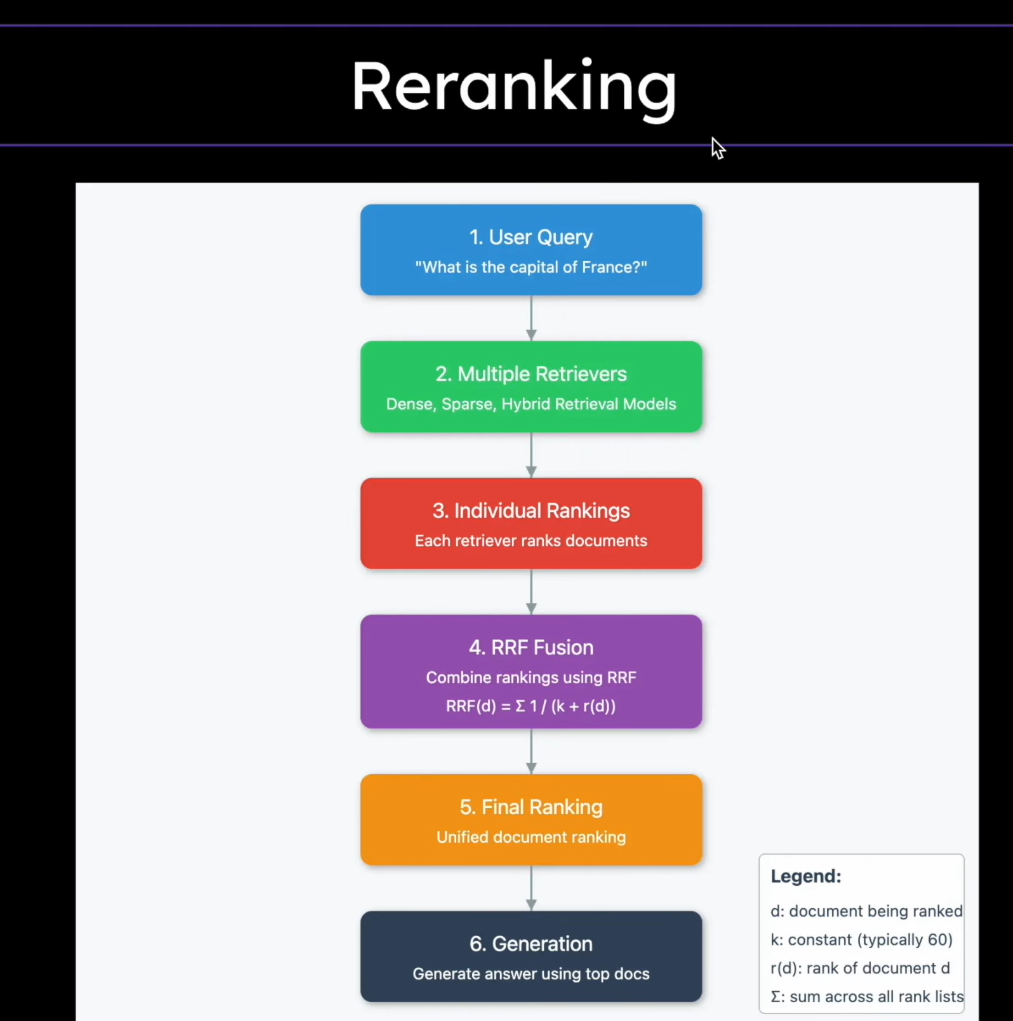